# SMIPS point time series workflow (TERN STAC API)
Load point-sampled values through time from STAC assets.


## Before you run
- Update placeholder values (`COLLECTION_ID`, dates, bounds, point coordinates) to match your data.
- Ensure auth is configured for protected assets (for example `.netrc` and/or GDAL config).
- Install optional dependencies required by this notebook's workflow (`odc-stac`, `rioxarray`, `geopandas`, plotting extras).
- Run cells from top to bottom so variables are initialized in order.


In [ ]:
from itertools import islice
from pathlib import Path

from tern_stac import TernStacClient, load_items_as_time_series, plot_time_series


In [ ]:
# Fill in from your catalog values
COLLECTION_ID = "model-derived_smips__v1_0_totalbucket_2024"
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"
REGION_BOUNDS = (152.914613, -27.561273, 153.142615, -27.367202)  # search window
REGION_BOUNDS_CRS = "EPSG:4326"

POINT_LON, POINT_LAT = 152.95, -27.47
POINT_CRS = "EPSG:4326"


In [ ]:
Path("outputs").mkdir(exist_ok=True)

client = TernStacClient()
search = client.search(
    collections=[COLLECTION_ID],
    datetime=f"{START_DATE}/{END_DATE}",
    bbox=[REGION_BOUNDS[0], REGION_BOUNDS[1], REGION_BOUNDS[2], REGION_BOUNDS[3]],
)
items = list(islice(search.items(), 10))
len(items)


In [ ]:
if not items:
    raise RuntimeError("No items returned. Update collection/date/bbox placeholders.")

ds = load_items_as_time_series(
    items,
    media_type=None,
    role="data",
    chunks=True,
    point=(POINT_LON, POINT_LAT),
    point_crs=POINT_CRS,
    to_numpy_nodata=True,
)
ds


In [ ]:
plot_time_series(
    ds,
    band_dim="band",
    figsize=(12, 6),
    compute=True,
    save_path="outputs/smips_time_series.png",
    title="SMIPS point time series by band",
)


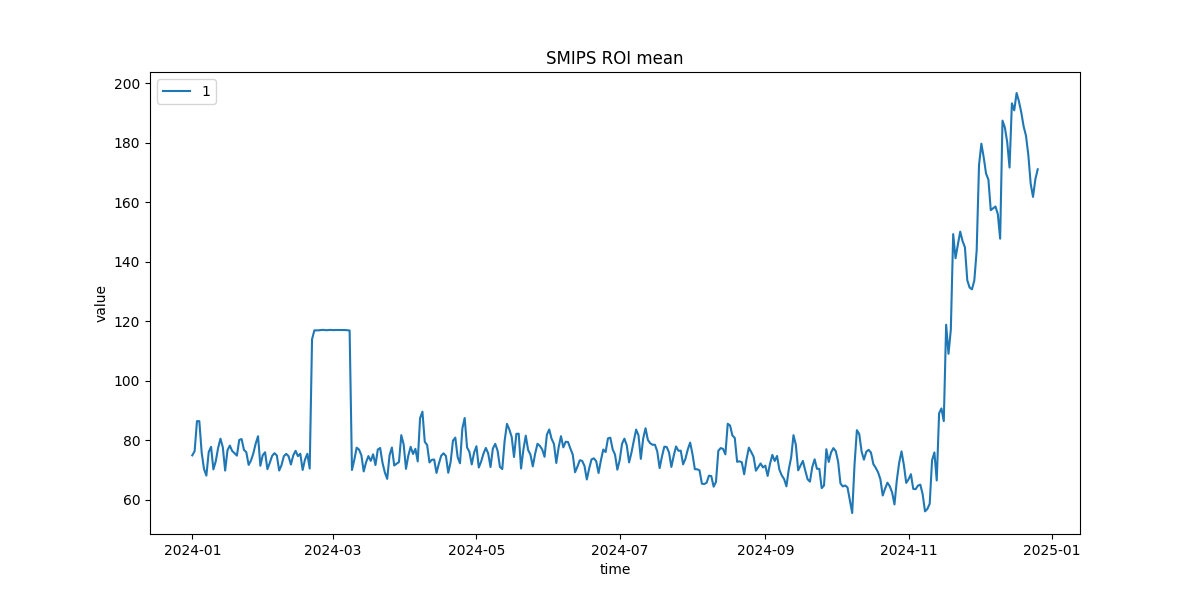